# 04 — Market EDA

**Étape 6 — EDA marché (distribution, saisonnalités, residual load, négatifs, spikes)**

Analyse exploratoire orientée marché : comprendre les drivers du prix avant
de faire du feature engineering ou de la modélisation (section 3, 4, 6, 13 du cahier).


## Setup

In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REPO_ROOT = Path(
    "/Users/evitafaj/Desktop/Portofolio/"
    "electricity-price-forecasting"
)

DATASET_PATH = (
    REPO_ROOT / "data" / "processed" / "dataset_v1.csv"
)

FIGURES_DIR = REPO_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.figsize"] = (14, 5)

df = pd.read_csv(
    DATASET_PATH,
    parse_dates=["datetime"],
    index_col="datetime",
)

df.index = pd.to_datetime(df.index, utc=True)
df = df.sort_index()

# Calendrier en heure française
local_index = df.index.tz_convert("Europe/Paris")

df["hour_local"] = local_index.hour
df["day_of_week"] = local_index.dayofweek
df["month"] = local_index.month
df["year"] = local_index.year

print("Dimensions :", df.shape)
print("Début UTC :", df.index.min())
print("Fin UTC :", df.index.max())
print("Doublons :", df.index.duplicated().sum())
print("Valeurs manquantes :", df.isna().sum().sum())

df.head()

Dimensions : (32855, 21)
Début UTC : 2021-12-31 23:00:00+00:00
Fin UTC : 2025-09-30 21:00:00+00:00
Doublons : 0
Valeurs manquantes : 0


,price_da,temperature_2m,wind_speed_10m,shortwave_radiation,demand_actual,demand_forecast_j1,oil_generation,coal_generation,gas_generation,nuclear_generation,wind_generation,solar_generation,hydro_generation,pumping_consumption,bioenergy_generation,net_import_mw,fundamentals_imputed,hour_local,day_of_week,month,year
datetime,,,,,,,,,,,,,,,,,,,,,
2021-12-31 23:00:00+00:00,89.06,9.4,3.111111,0.0,54315.0,50787.5,94.0,13.5,2826.0,40497.0,3187.5,0.0,9465.5,-264.0,1247.5,-2679.0,0,0,5,1,2022
2022-01-01 00:00:00+00:00,78.48,10.7,2.500000,0.0,52173.5,49162.5,99.0,13.5,2693.0,38645.5,3270.0,0.0,9108.0,-65.0,1255.0,-2768.5,0,1,5,1,2022
2022-01-01 01:00:00+00:00,85.16,9.3,2.638889,0.0,51527.5,47550.0,99.0,13.0,2687.0,38081.0,3146.0,0.0,8427.0,-602.5,1250.5,-1491.0,0,2,5,1,2022
2022-01-01 02:00:00+00:00,50.00,8.8,2.833333,0.0,48845.5,44687.5,99.0,13.0,2694.0,37259.5,3273.5,0.0,6787.0,-1459.5,1247.5,-986.5,0,3,5,1,2022
2022-01-01 03:00:00+00:00,37.67,8.2,2.944444,0.0,46646.0,43075.0,99.0,13.0,2699.5,36374.5,3481.5,0.0,6443.0,-2638.0,1253.5,-1001.0,0,4,5,1,2022


## Statistiques descriptives du prix (mean, variance, quantiles) — section 7.1

In [2]:
price_stats = df["price_da"].describe(
    percentiles=[
        0.01,
        0.05,
        0.25,
        0.50,
        0.75,
        0.95,
        0.99,
    ]
)

display(price_stats.to_frame("price_da"))

print("Variance :", df["price_da"].var())
print("Asymétrie :", df["price_da"].skew())
print("Kurtosis :", df["price_da"].kurt())
print("Prix négatifs :", (df["price_da"] < 0).sum())
print("Prix nuls :", (df["price_da"] == 0).sum())

,price_da
count,32855.000000
mean,127.020701
std,124.330870
min,-134.940000
1%,-3.456800
5%,0.090000
25%,50.000000
50%,95.000000
75%,159.475000
95%,395.880000


Variance : 15458.165341647013
Asymétrie : 2.516277045363328
Kurtosis : 18.55195846270354
Prix négatifs : 996
Prix nuls : 453


## Distribution des prix : histogramme, boxplot par heure / mois / jour de semaine

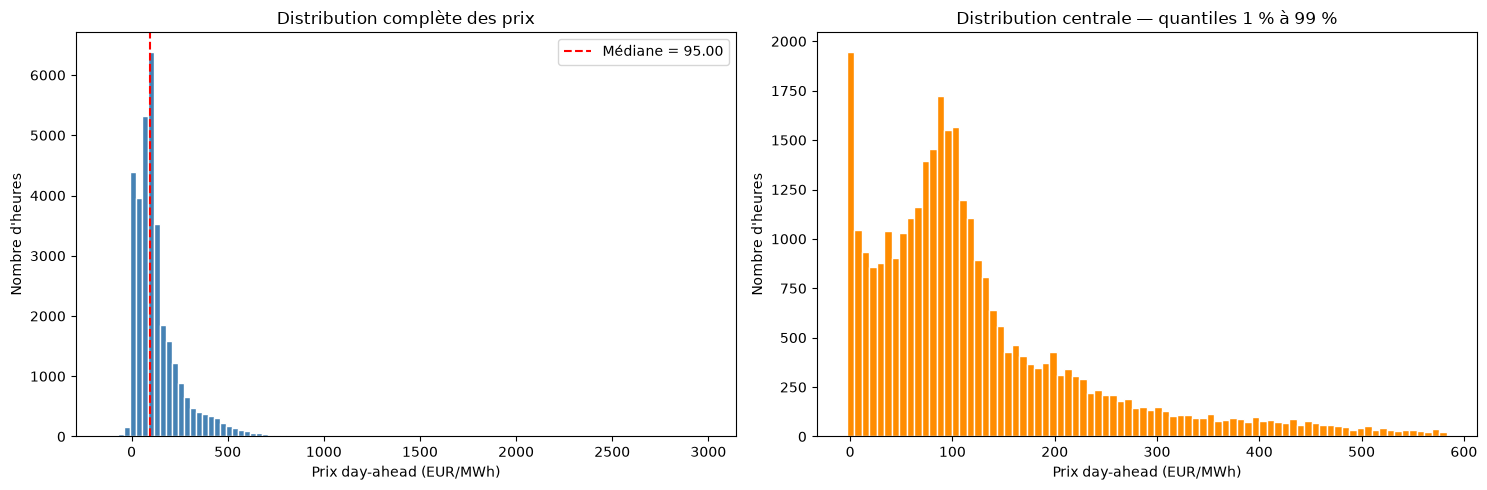

In [3]:
price = df["price_da"]

q01 = price.quantile(0.01)
q99 = price.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(
    price,
    bins=100,
    color="steelblue",
    edgecolor="white",
)

axes[0].axvline(
    price.median(),
    color="red",
    linestyle="--",
    label=f"Médiane = {price.median():.2f}",
)

axes[0].set_title("Distribution complète des prix")
axes[0].set_xlabel("Prix day-ahead (EUR/MWh)")
axes[0].set_ylabel("Nombre d'heures")
axes[0].legend()

central_prices = price[
    price.between(q01, q99)
]

axes[1].hist(
    central_prices,
    bins=80,
    color="darkorange",
    edgecolor="white",
)

axes[1].set_title(
    "Distribution centrale — quantiles 1 % à 99 %"
)
axes[1].set_xlabel("Prix day-ahead (EUR/MWh)")
axes[1].set_ylabel("Nombre d'heures")

plt.tight_layout()
plt.show()

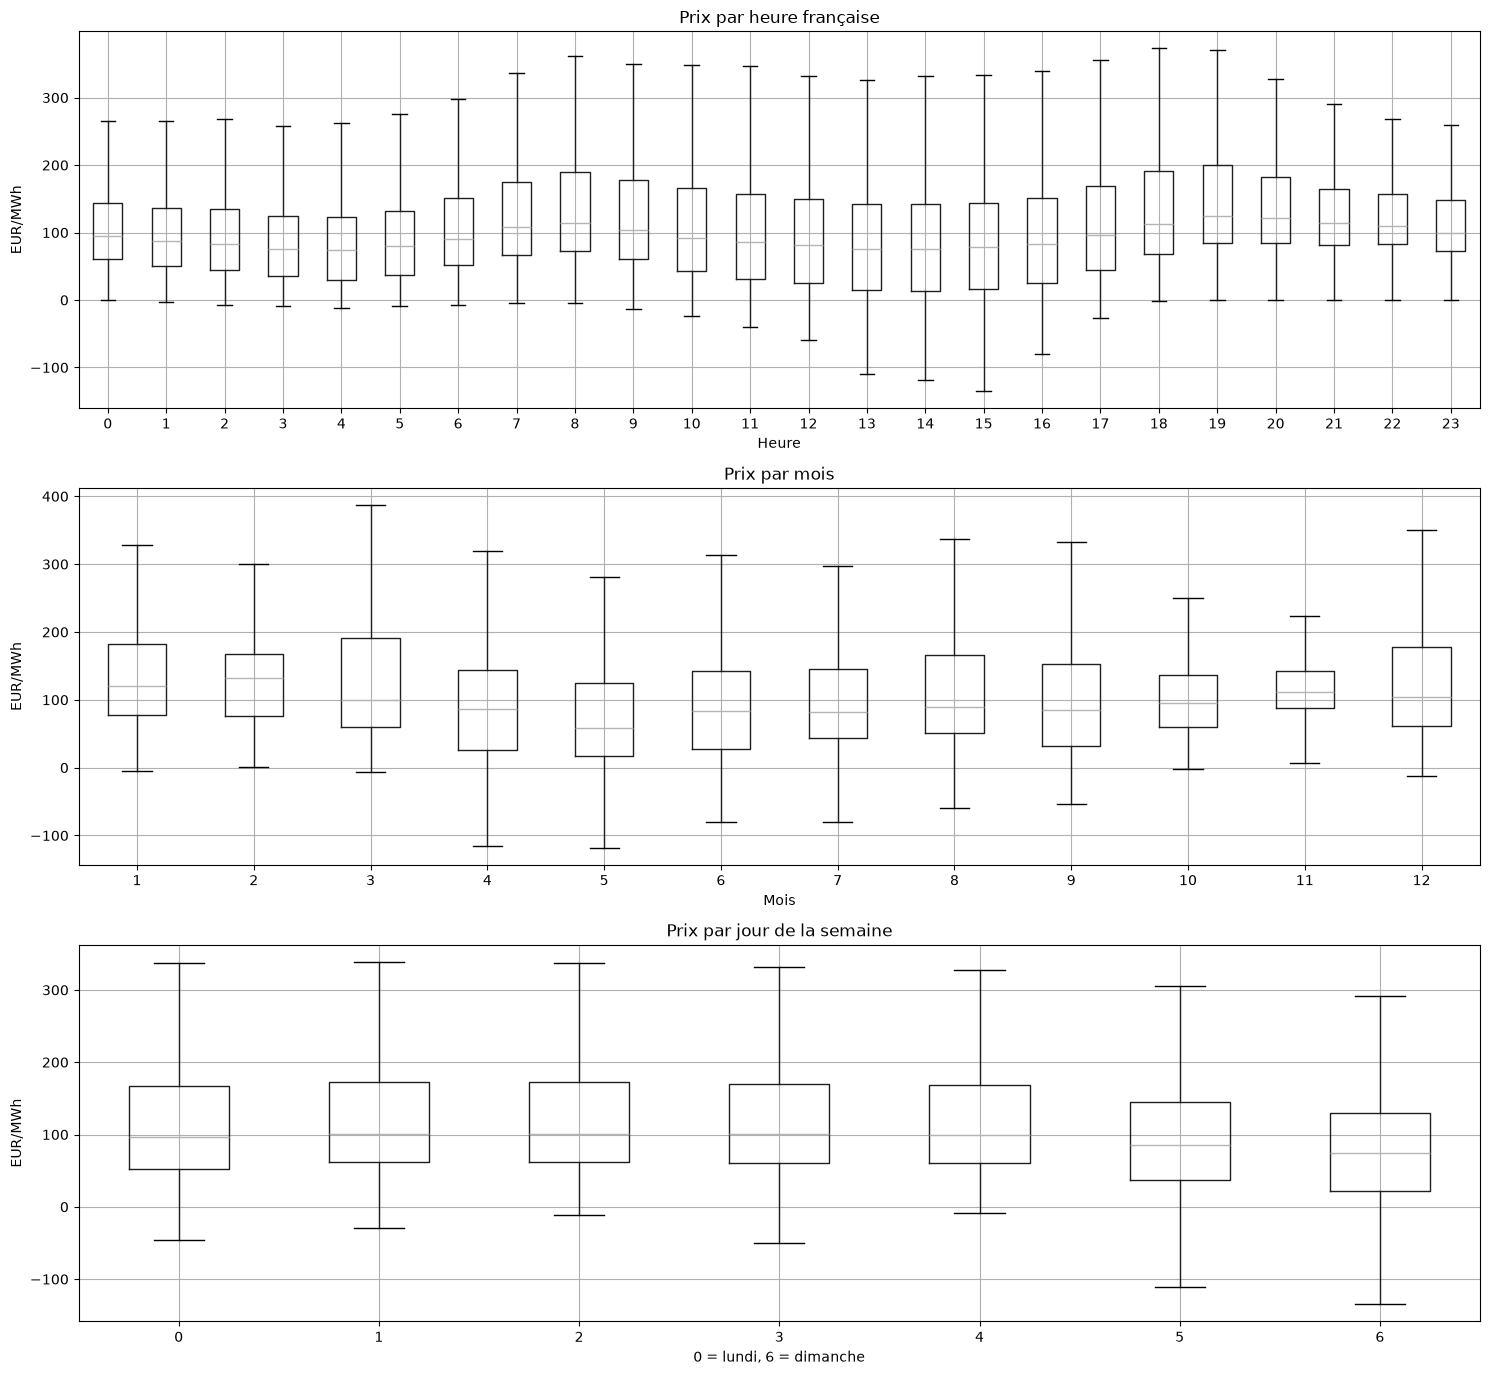

In [6]:
fig, axes = plt.subplots(
    3,
    1,
    figsize=(15, 14),
)

df.boxplot(
    column="price_da",
    by="hour_local",
    ax=axes[0],
    showfliers=False,
)

axes[0].set_title("Prix par heure française")
axes[0].set_xlabel("Heure")
axes[0].set_ylabel("EUR/MWh")

df.boxplot(
    column="price_da",
    by="month",
    ax=axes[1],
    showfliers=False,
)

axes[1].set_title("Prix par mois")
axes[1].set_xlabel("Mois")
axes[1].set_ylabel("EUR/MWh")

df.boxplot(
    column="price_da",
    by="day_of_week",
    ax=axes[2],
    showfliers=False,
)

axes[2].set_title("Prix par jour de la semaine")
axes[2].set_xlabel("0 = lundi, 6 = dimanche")
axes[2].set_ylabel("EUR/MWh")

plt.suptitle("")
plt.tight_layout()
plt.show()

## Construction et analyse du residual load (Demand - Wind - Solar) — section 3.3

,demand_actual,wind_generation,solar_generation,residual_load_actual
count,32855.000000,32855.000000,32855.000000,32855.000000
mean,50212.891173,5143.748752,2812.914153,42256.228268
std,10637.206199,4009.221834,4056.912567,11079.014686
min,29916.500000,61.000000,0.000000,14769.500000
25%,42428.500000,2093.250000,0.000000,34317.250000
50%,48485.500000,3892.500000,149.500000,39974.500000
75%,56884.000000,7211.000000,5029.750000,47850.500000
max,87702.500000,19802.000000,21579.000000,85167.500000


Corrélation Pearson prix / residual load : 0.34657545790477723
Corrélation Spearman prix / residual load : 0.5422819397072333


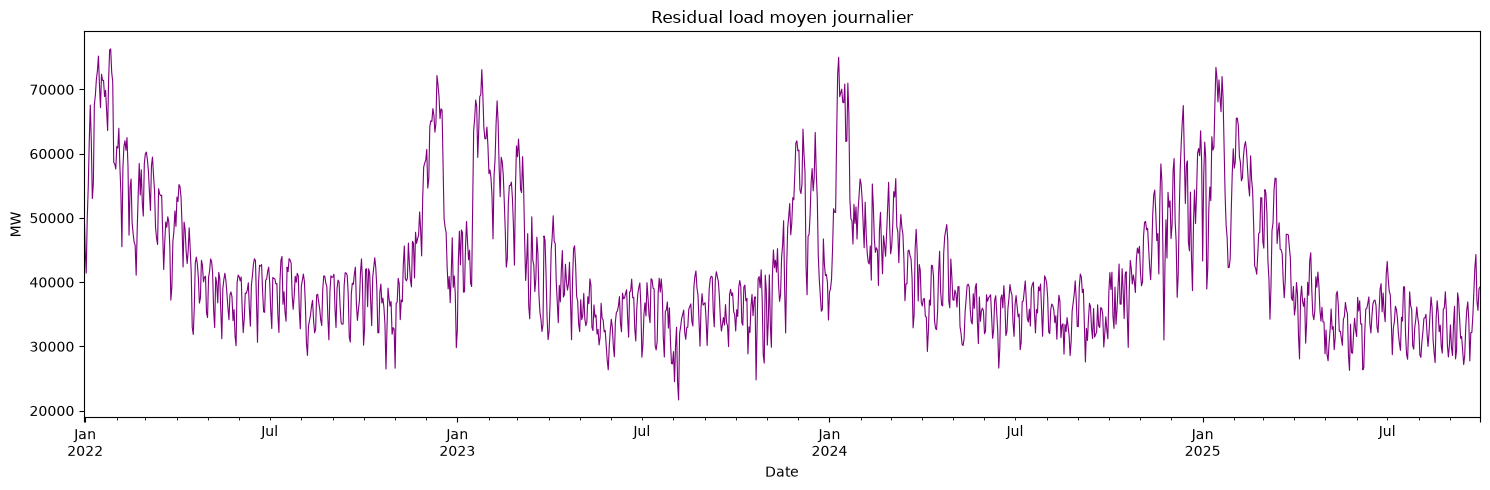

In [7]:
df["residual_load_actual"] = (
    df["demand_actual"]
    - df["wind_generation"]
    - df["solar_generation"]
)

display(
    df[
        [
            "demand_actual",
            "wind_generation",
            "solar_generation",
            "residual_load_actual",
        ]
    ].describe()
)

print(
    "Corrélation Pearson prix / residual load :",
    df["price_da"].corr(
        df["residual_load_actual"],
        method="pearson",
    ),
)

print(
    "Corrélation Spearman prix / residual load :",
    df["price_da"].corr(
        df["residual_load_actual"],
        method="spearman",
    ),
)

daily_residual = (
    df["residual_load_actual"]
    .resample("D")
    .mean()
)

fig, ax = plt.subplots(figsize=(15, 5))

daily_residual.plot(
    ax=ax,
    linewidth=0.8,
    color="purple",
)

ax.set_title("Residual load moyen journalier")
ax.set_ylabel("MW")
ax.set_xlabel("Date")

plt.tight_layout()
plt.show()

## Prix vs residual load (scatter) — intuition merit order, section 3.2

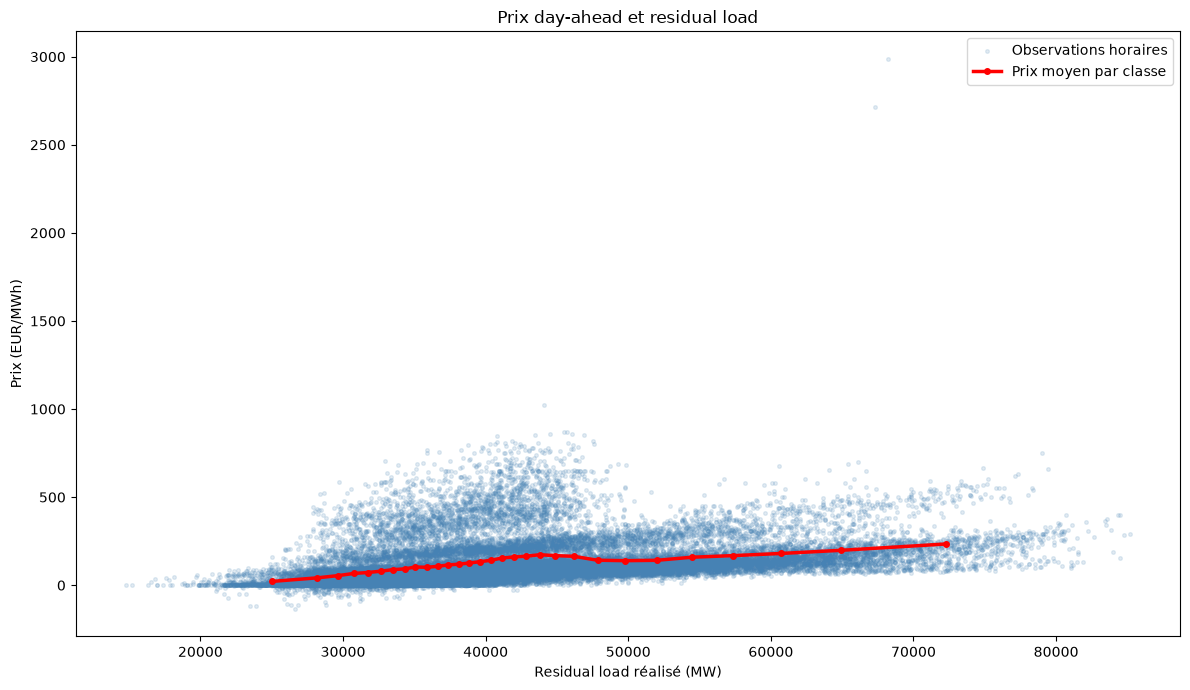

In [8]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    df["residual_load_actual"],
    df["price_da"],
    s=7,
    alpha=0.15,
    color="steelblue",
    label="Observations horaires",
)

# Moyenne du prix par classe de residual load
residual_bins = pd.qcut(
    df["residual_load_actual"],
    q=30,
    duplicates="drop",
)

binned_relation = (
    df.assign(residual_bin=residual_bins)
    .groupby(
        "residual_bin",
        observed=True,
    )
    .agg(
        residual_load_mean=(
            "residual_load_actual",
            "mean",
        ),
        price_mean=("price_da", "mean"),
    )
)

ax.plot(
    binned_relation["residual_load_mean"],
    binned_relation["price_mean"],
    color="red",
    linewidth=2.5,
    marker="o",
    markersize=4,
    label="Prix moyen par classe",
)

ax.set_title("Prix day-ahead et residual load")
ax.set_xlabel("Residual load réalisé (MW)")
ax.set_ylabel("Prix (EUR/MWh)")
ax.legend()

plt.tight_layout()
plt.show()

## Analyse des heures à prix négatif (section 6.2 et 13.1) : comparer demande/vent/solaire/heure

In [9]:
df["is_negative_price"] = (
    df["price_da"] < 0
)

negative_count = int(
    df["is_negative_price"].sum()
)

negative_share = (
    df["is_negative_price"].mean() * 100
)

print("Nombre d'heures négatives :", negative_count)
print(f"Part des heures négatives : {negative_share:.2f} %")

negative_comparison_columns = [
    "price_da",
    "demand_actual",
    "wind_generation",
    "solar_generation",
    "nuclear_generation",
    "net_import_mw",
    "residual_load_actual",
]

negative_comparison = (
    df.groupby("is_negative_price")[
        negative_comparison_columns
    ]
    .mean()
    .T
)

negative_comparison.columns = [
    "prix_non_negatif",
    "prix_negatif",
]

display(negative_comparison)

Nombre d'heures négatives : 996
Part des heures négatives : 3.03 %


,prix_non_negatif,prix_negatif
price_da,131.239707,-7.932450
demand_actual,50409.019131,43939.356426
wind_generation,5182.746437,3896.331827
solar_generation,2633.935309,8537.901104
nuclear_generation,37643.867683,30663.327811
net_import_mw,-5835.600089,-4319.037651
residual_load_actual,42592.337385,31505.123494


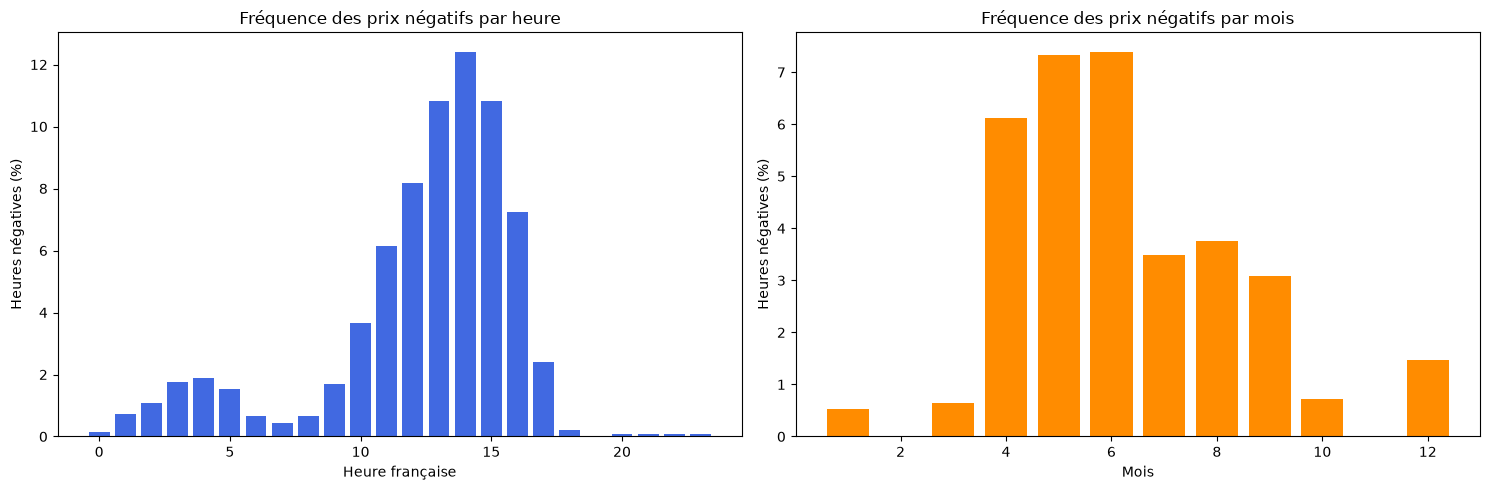

In [10]:
negative_by_hour = (
    df.groupby("hour_local")["is_negative_price"]
    .agg(["sum", "mean"])
)

negative_by_month = (
    df.groupby("month")["is_negative_price"]
    .agg(["sum", "mean"])
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
)

axes[0].bar(
    negative_by_hour.index,
    negative_by_hour["mean"] * 100,
    color="royalblue",
)

axes[0].set_title("Fréquence des prix négatifs par heure")
axes[0].set_xlabel("Heure française")
axes[0].set_ylabel("Heures négatives (%)")

axes[1].bar(
    negative_by_month.index,
    negative_by_month["mean"] * 100,
    color="darkorange",
)

axes[1].set_title("Fréquence des prix négatifs par mois")
axes[1].set_xlabel("Mois")
axes[1].set_ylabel("Heures négatives (%)")

plt.tight_layout()
plt.show()

## Analyse des spikes (seuil = quantile 95/99 du train, section 13.2)

In [11]:
train_start = pd.Timestamp(
    "2022-01-01",
    tz="Europe/Paris",
).tz_convert("UTC")

validation_start = pd.Timestamp(
    "2024-01-01",
    tz="Europe/Paris",
).tz_convert("UTC")

test_start = pd.Timestamp(
    "2025-01-01",
    tz="Europe/Paris",
).tz_convert("UTC")

test_end = pd.Timestamp(
    "2025-10-01",
    tz="Europe/Paris",
).tz_convert("UTC")

df["split"] = "test"

df.loc[
    (df.index >= train_start)
    & (df.index < validation_start),
    "split",
] = "train"

df.loc[
    (df.index >= validation_start)
    & (df.index < test_start),
    "split",
] = "validation"

train_prices = df.loc[
    df["split"] == "train",
    "price_da",
]

spike_threshold_95 = train_prices.quantile(0.95)
spike_threshold_99 = train_prices.quantile(0.99)

df["is_spike_q95"] = (
    df["price_da"] > spike_threshold_95
)

df["is_spike_q99"] = (
    df["price_da"] > spike_threshold_99
)

print(
    f"Seuil Q95 appris sur le train : "
    f"{spike_threshold_95:.2f} EUR/MWh"
)

print(
    f"Seuil Q99 appris sur le train : "
    f"{spike_threshold_99:.2f} EUR/MWh"
)

spike_summary = (
    df.groupby("split")[
        ["is_spike_q95", "is_spike_q99"]
    ]
    .agg(["sum", "mean"])
)

display(spike_summary)

Seuil Q95 appris sur le train : 472.38 EUR/MWh
Seuil Q99 appris sur le train : 650.00 EUR/MWh


is_spike_q95           is_spike_q99         
                    sum      mean          sum     mean
split                                                  
test                  1  0.000153            0  0.00000
train               876  0.050000          154  0.00879
validation            0  0.000000            0  0.00000

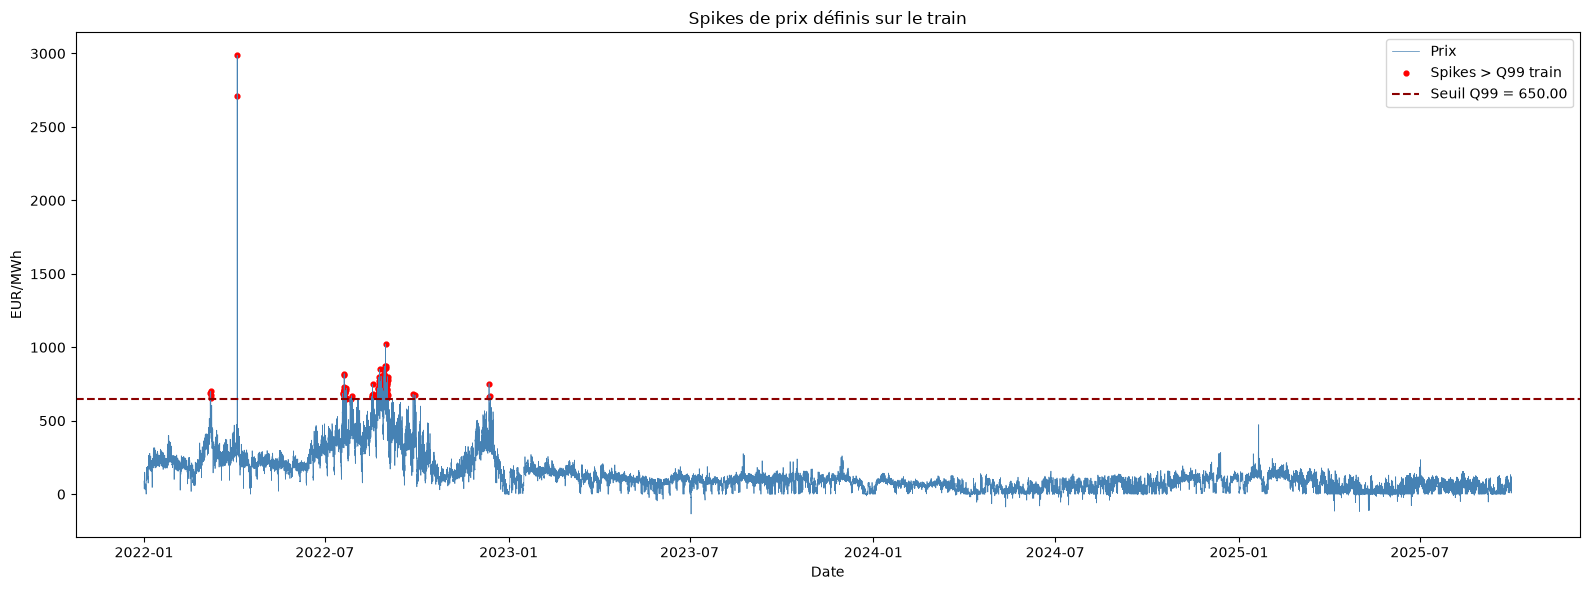

In [12]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    df.index,
    df["price_da"],
    linewidth=0.5,
    color="steelblue",
    label="Prix",
)

q99_points = df[df["is_spike_q99"]]

ax.scatter(
    q99_points.index,
    q99_points["price_da"],
    color="red",
    s=12,
    label="Spikes > Q99 train",
)

ax.axhline(
    spike_threshold_99,
    color="darkred",
    linestyle="--",
    label=f"Seuil Q99 = {spike_threshold_99:.2f}",
)

ax.set_title("Spikes de prix définis sur le train")
ax.set_ylabel("EUR/MWh")
ax.set_xlabel("Date")
ax.legend()

plt.tight_layout()
plt.show()

## Corrélations entre fondamentaux et prix

,correlation_spearman_avec_prix
wind_generation,-0.225502
temperature_2m,-0.192855
wind_speed_10m,-0.161451
solar_generation,-0.132862
nuclear_generation,-0.119053
shortwave_radiation,-0.106195
bioenergy_generation,-0.069545
hydro_generation,-0.020852
oil_generation,0.249458
demand_actual,0.310044


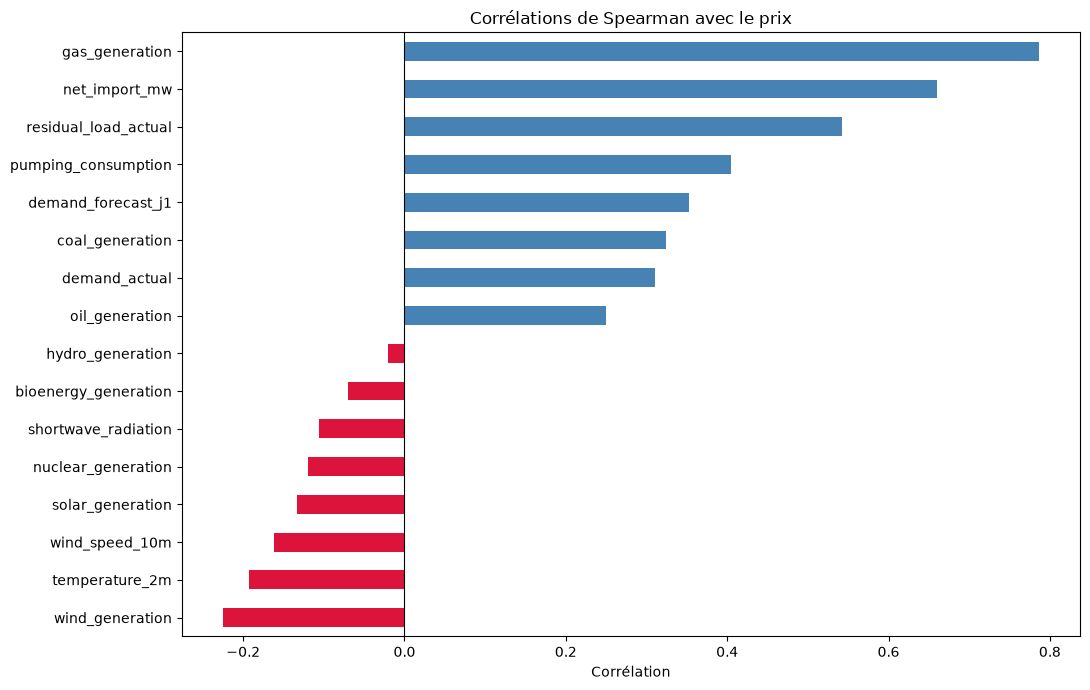

In [13]:
correlation_columns = [
    "price_da",
    "demand_actual",
    "demand_forecast_j1",
    "oil_generation",
    "coal_generation",
    "gas_generation",
    "nuclear_generation",
    "wind_generation",
    "solar_generation",
    "hydro_generation",
    "pumping_consumption",
    "bioenergy_generation",
    "net_import_mw",
    "temperature_2m",
    "wind_speed_10m",
    "shortwave_radiation",
    "residual_load_actual",
]

correlation_matrix = df[
    correlation_columns
].corr(method="spearman")

price_correlations = (
    correlation_matrix["price_da"]
    .drop("price_da")
    .sort_values()
)

display(
    price_correlations.to_frame(
        "correlation_spearman_avec_prix"
    )
)

fig, ax = plt.subplots(figsize=(11, 7))

colors = [
    "crimson" if value < 0 else "steelblue"
    for value in price_correlations
]

price_correlations.plot.barh(
    ax=ax,
    color=colors,
)

ax.axvline(
    0,
    color="black",
    linewidth=0.8,
)

ax.set_title(
    "Corrélations de Spearman avec le prix"
)
ax.set_xlabel("Corrélation")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

## Saisonnalité : profils horaires, hebdomadaires, mensuels

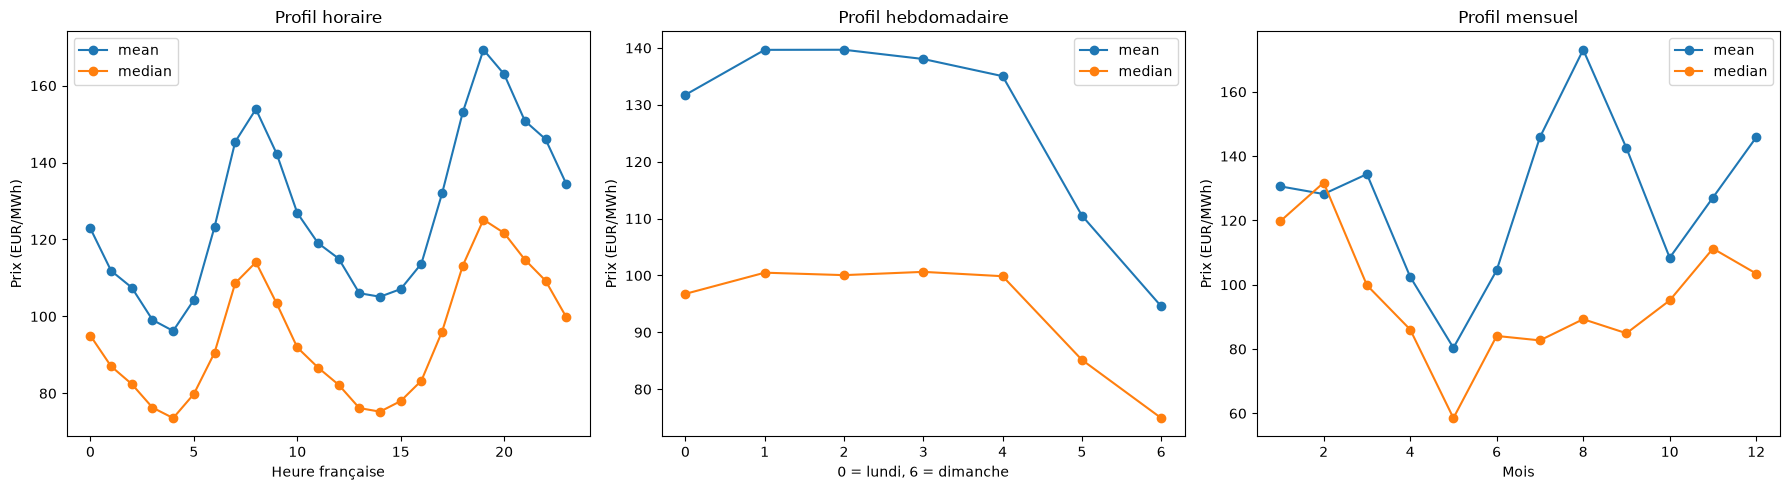

In [14]:
hourly_profile = (
    df.groupby("hour_local")["price_da"]
    .agg(["mean", "median"])
)

weekly_profile = (
    df.groupby("day_of_week")["price_da"]
    .agg(["mean", "median"])
)

monthly_profile = (
    df.groupby("month")["price_da"]
    .agg(["mean", "median"])
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)

hourly_profile.plot(
    ax=axes[0],
    marker="o",
)

axes[0].set_title("Profil horaire")
axes[0].set_xlabel("Heure française")
axes[0].set_ylabel("Prix (EUR/MWh)")

weekly_profile.plot(
    ax=axes[1],
    marker="o",
)

axes[1].set_title("Profil hebdomadaire")
axes[1].set_xlabel("0 = lundi, 6 = dimanche")
axes[1].set_ylabel("Prix (EUR/MWh)")

monthly_profile.plot(
    ax=axes[2],
    marker="o",
)

axes[2].set_title("Profil mensuel")
axes[2].set_xlabel("Mois")
axes[2].set_ylabel("Prix (EUR/MWh)")

plt.tight_layout()
plt.show()